In [1]:
!pip install pandas
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install matplotlib
!pip install seaborn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [3]:
import pandas as pd

df = pd.read_csv("D:/Hackathon Projects/ML-Service/app/data/zone_risk_history_final_10k.csv")

print(df.shape)
df.head()

(10000, 9)


,pincode,city,avg_rainfall,heavy_rain_days,avg_wind_speed,avg_pressure,storm_days,avg_aqi,disruption_frequency_score
0,770487,Jaipur,4.44,8,13.73,1007.24,0,81.52,0.421625
1,216739,Ahmedabad,5.04,11,16.08,1008.26,4,97.91,0.533162
2,126225,Jaipur,0.25,2,13.23,1006.48,2,131.62,0.623318
3,877572,Pune,30.72,7,17.85,1013.03,0,68.33,0.355226
4,388389,Pune,-5.49,0,17.07,1009.56,0,84.09,0.384589


In [4]:
features = [
    "avg_rainfall",
    "heavy_rain_days",
    "avg_wind_speed",
    "avg_pressure",
    "storm_days",
    "avg_aqi",
    "disruption_frequency_score"
]

X = df[features].copy()

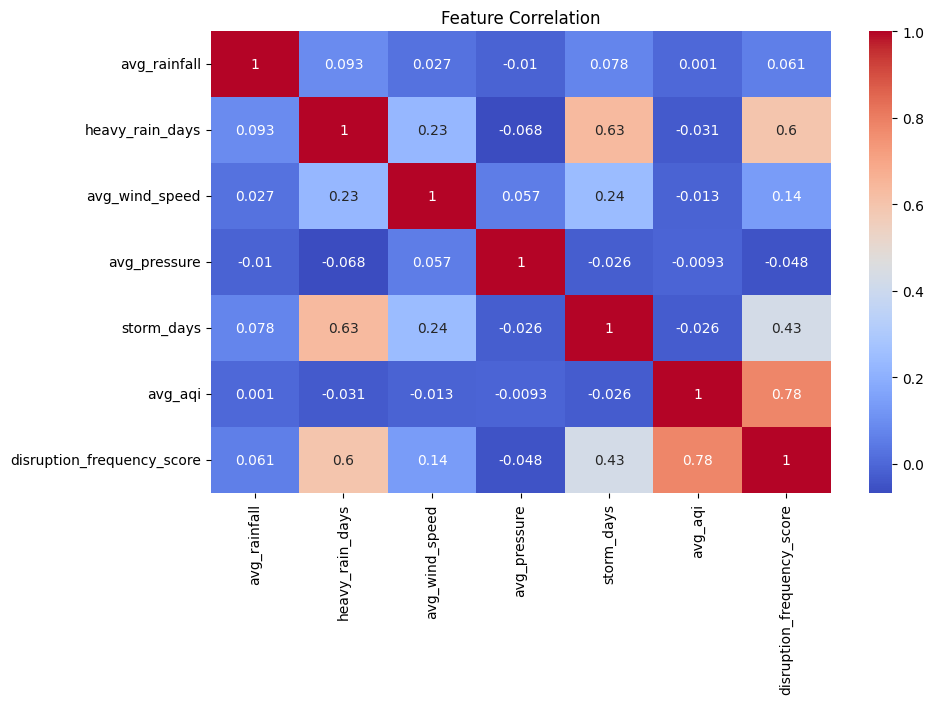

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [16]:
X["avg_rainfall"] = np.log1p(X["avg_rainfall"])
X["avg_aqi"] = np.log1p(X["avg_aqi"])

d:\Practice Projects\ML_projects\Projects\Project_1-Price Optimization using Regression+Elasticity Modeling\Demandex\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\Practice Projects\ML_projects\Projects\Project_1-Price Optimization using Regression+Elasticity Modeling\Demandex\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [17]:
X["risk_index"] = (
    0.3 * X["avg_rainfall"] +
    0.2 * X["storm_days"] +
    0.2 * X["heavy_rain_days"] +
    0.2 * X["avg_aqi"] +
    0.1 * X["avg_wind_speed"]
)

In [18]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X_clean = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Before:", X.shape)
print("After:", X_clean.shape)

Before: (9614, 8)
After: (8367, 8)


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

In [21]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clean.columns)


In [22]:
X_scaled_df.isnull().sum()

avg_rainfall                  3032
heavy_rain_days                  0
avg_wind_speed                   0
avg_pressure                     0
storm_days                       0
avg_aqi                          0
disruption_frequency_score       0
risk_index                    3032
dtype: int64

In [23]:
# Fill missing values (robust approach)
X["avg_rainfall"] = X["avg_rainfall"].fillna(X["avg_rainfall"].median())

# Recompute risk_index AFTER fixing NaN
X["risk_index"] = (
    0.3 * X["avg_rainfall"] +
    0.2 * X["storm_days"] +
    0.2 * X["heavy_rain_days"] +
    0.2 * X["avg_aqi"] +
    0.1 * X["avg_wind_speed"]
)

In [24]:
features = [
    "avg_rainfall",
    "heavy_rain_days",
    "avg_wind_speed",
    "avg_pressure",
    "storm_days",
    "avg_aqi",
    "risk_index"
]

In [42]:
# 1. Handle missing
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# 2. Log transform
X["avg_rainfall"] = np.log1p(X["avg_rainfall"].clip(lower=0))
X["avg_aqi"] = np.log1p(X["avg_aqi"].clip(lower=0))

# 3. Create risk_index
X["risk_index"] = (
    0.3 * X["avg_rainfall"] +
    0.2 * X["storm_days"] +
    0.2 * X["heavy_rain_days"] +
    0.2 * X["avg_aqi"] +
    0.1 * X["avg_wind_speed"]
)

# 4. Remove outliers (IQR)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X_clean = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]

# 5. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

In [27]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clean.columns)
X_scaled_df.isnull().sum()

avg_rainfall                  110
heavy_rain_days                 0
avg_wind_speed                  0
avg_pressure                    0
storm_days                      0
avg_aqi                         0
disruption_frequency_score      0
risk_index                    110
dtype: int64

In [28]:
X["avg_rainfall"] = X["avg_rainfall"].fillna(X["avg_rainfall"].median())

# Recompute risk_index AFTER fill
X["risk_index"] = (
    0.3 * X["avg_rainfall"] +
    0.2 * X["storm_days"] +
    0.2 * X["heavy_rain_days"] +
    0.2 * X["avg_aqi"] +
    0.1 * X["avg_wind_speed"]
)

In [29]:
print(X.isnull().sum())

avg_rainfall                  0
heavy_rain_days               0
avg_wind_speed                0
avg_pressure                  0
storm_days                    0
avg_aqi                       0
disruption_frequency_score    0
risk_index                    0
dtype: int64


In [43]:
sil_scores = []
db_scores = []

k_range = range(2, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)

    sil_scores.append(sil)
    db_scores.append(db)

    print(f"K={k} | Silhouette={sil:.4f} | DB={db:.4f}")

K=2 | Silhouette=0.2360 | DB=1.7034
K=3 | Silhouette=0.1739 | DB=1.7461
K=4 | Silhouette=0.1529 | DB=1.8484
K=5 | Silhouette=0.1384 | DB=1.8728
K=6 | Silhouette=0.1376 | DB=1.8086
K=7 | Silhouette=0.1386 | DB=1.6926
K=8 | Silhouette=0.1262 | DB=1.7134
K=9 | Silhouette=0.1290 | DB=1.6350


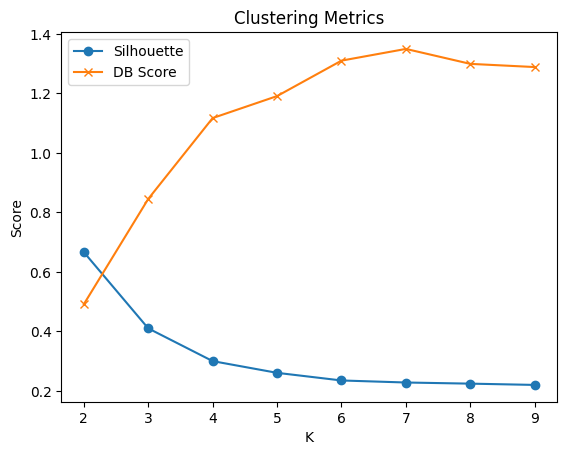

In [31]:
plt.plot(k_range, sil_scores, marker='o', label="Silhouette")
plt.plot(k_range, db_scores, marker='x', label="DB Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.title("Clustering Metrics")
plt.legend()
plt.show()

In [50]:
BEST_K = 2  # <-- CHANGE THIS BASED ON YOUR RESULT

kmeans = KMeans(n_clusters=BEST_K, random_state=42)
labels = kmeans.fit_predict(X_scaled)

print("Final Silhouette:", silhouette_score(X_scaled, labels))
print("Final DB Score:", davies_bouldin_score(X_scaled, labels))

Final Silhouette: 0.23597721552181072
Final DB Score: 1.7034013357588969


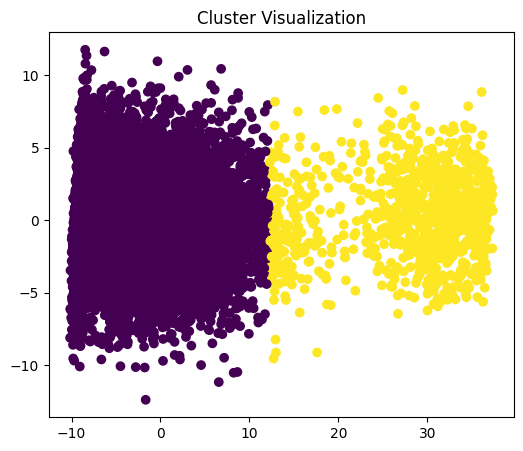

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("Cluster Visualization")
plt.show()

In [51]:
df_clean = df.loc[X_clean.index].copy()
df_clean["cluster"] = labels

In [52]:
df_clean = df_clean.sort_values(by="disruption_frequency_score")

df_clean["zone_risk_tier"] = pd.qcut(
    df_clean["disruption_frequency_score"],
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

In [54]:
df_clean["risk_index"] = X_clean["risk_index"]


In [55]:
df_clean.isnull().sum()

pincode                       0
city                          0
avg_rainfall                  0
heavy_rain_days               0
avg_wind_speed                0
avg_pressure                  0
storm_days                    0
avg_aqi                       0
disruption_frequency_score    0
cluster                       0
zone_risk_tier                0
risk_index                    0
dtype: int64